# Data Preprocessing & Feature Engineering

This notebook handles the cleaning and transformation of the delivery delay dataset. 
It implements both **Conventional** methods (Scaling, Encoding) and **Unconventional** methods (Feature Engineering, Log Transforms).

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# Ensure output directory exists
os.makedirs('../data/processed', exist_ok=True)

In [24]:
# Load Dataset
df = pd.read_csv('../data/raw/delivery_delay_dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5000, 9)


,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status
0,112,43.767328,2073.415113,3,2,46.328035,0.202138,0.575776,At Risk
1,445,18.733949,1542.736319,4,2,74.962882,0.598503,0.754245,At Risk
2,358,46.311686,1953.566537,2,2,61.875741,0.587153,0.743008,Delayed
3,280,5.196608,2669.613801,4,2,68.762909,0.467294,0.671604,At Risk
4,116,33.289906,1324.101539,1,1,38.565538,0.012040,0.334061,On-Time


## 1. Initial Exploration (EDA)

order_volume            0
warehouse_time_hrs      0
shipment_distance_km    0
traffic_level           0
weather_severity        0
courier_load_pct        0
past_delay_rate         0
risk_score              0
delivery_status         0
dtype: int64


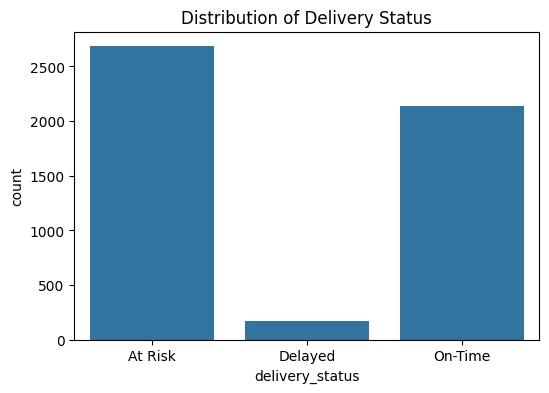

In [25]:
# Check for missing values
print(df.isnull().sum())

# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='delivery_status', data=df)
plt.title('Distribution of Delivery Status')
plt.show()

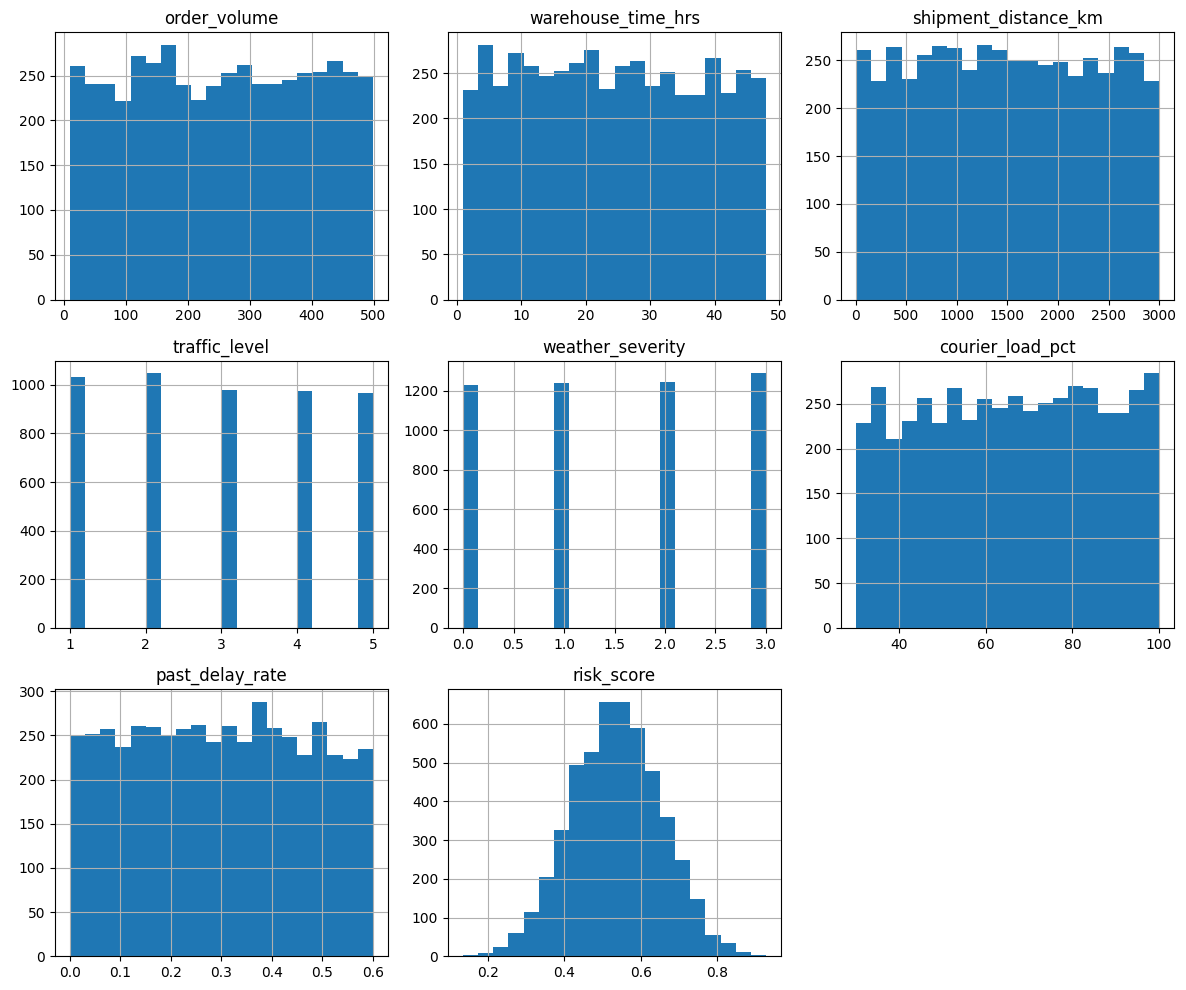

In [26]:
# Numerical Feature Distributions
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

## 2. Conventional Preprocessing

In [27]:
# Target Encoding: Convert labels to numbers
# On-Time -> 0, At Risk -> 1, Delayed -> 2
status_map = {"On-Time": 0, "At Risk": 1, "Delayed": 2}
df['delivery_status_encoded'] = df['delivery_status'].map(status_map)

print("Mapping applied:", status_map)
df[['delivery_status', 'delivery_status_encoded']].head()

Mapping applied: {'On-Time': 0, 'At Risk': 1, 'Delayed': 2}


,delivery_status,delivery_status_encoded
0,At Risk,1
1,At Risk,1
2,Delayed,2
3,At Risk,1
4,On-Time,0


In [28]:
# Feature Scaling: StandardScaler
# Applied to continuous variables
scaler = StandardScaler()
num_cols = ['order_volume', 'warehouse_time_hrs', 'shipment_distance_km', 'courier_load_pct', 'past_delay_rate']

for col in num_cols:
    df[f'{col}_scaled'] = scaler.fit_transform(df[[col]])
    
print("Scaled columns added.")
df.head()

Scaled columns added.


,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status,delivery_status_encoded,order_volume_scaled,warehouse_time_hrs_scaled,shipment_distance_km_scaled,courier_load_pct_scaled,past_delay_rate_scaled
0,112,43.767328,2073.415113,3,2,46.328035,0.202138,0.575776,At Risk,1,-1.010950,1.444502,0.673604,-0.958146,-0.552791
1,445,18.733949,1542.736319,4,2,74.962882,0.598503,0.754245,At Risk,1,1.342111,-0.406326,0.057050,0.456879,1.766605
2,358,46.311686,1953.566537,2,2,61.875741,0.587153,0.743008,Delayed,2,0.727347,1.632617,0.534361,-0.189838,1.700184
3,280,5.196608,2669.613801,4,2,68.762909,0.467294,0.671604,At Risk,1,0.176180,-1.407201,1.366280,0.150500,0.998813
4,116,33.289906,1324.101539,1,1,38.565538,0.012040,0.334061,On-Time,0,-0.982685,0.669860,-0.196965,-1.341738,-1.665176


## 3. Unconventional Preprocessing (Feature Engineering)

In [29]:
# A. Interaction Feature: Severity Index
# Combines Traffic Level (1-5) and Weather Severity (0-3)
# Logic: Bad weather amplifies the effect of traffic.
df['severity_index'] = df['traffic_level'] * (df['weather_severity'] + 1)

# B. Efficiency Ratio: Warehouse Efficiency
# Logic: Distance covered per hour of warehouse prep time.
# Indicates how "worth it" the prep time was for the journey ahead.
df['warehouse_efficiency'] = df['shipment_distance_km'] / df['warehouse_time_hrs']

df[['traffic_level', 'weather_severity', 'severity_index', 'warehouse_efficiency']].head()

,traffic_level,weather_severity,severity_index,warehouse_efficiency
0,3,2,9,47.373583
1,4,2,12,82.349768
2,2,2,6,42.183015
3,4,2,12,513.722409
4,1,1,2,39.774866


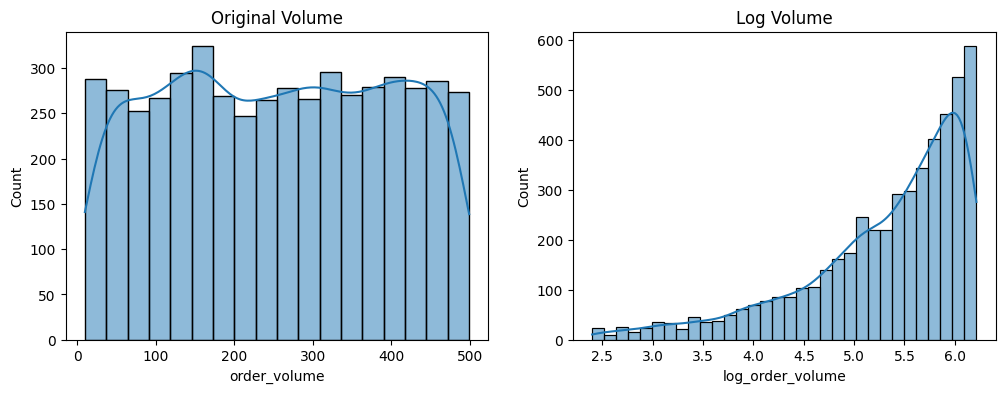

In [30]:
# C. Log Transformations
# Address skewness in Volume and Distance
df['log_order_volume'] = np.log1p(df['order_volume'])
df['log_shipment_distance'] = np.log1p(df['shipment_distance_km'])

# Visualize effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['order_volume'], ax=axes[0], kde=True)
axes[0].set_title('Original Volume')
sns.histplot(df['log_order_volume'], ax=axes[1], kde=True)
axes[1].set_title('Log Volume')
plt.show()

In [31]:
# D. Binning / Discretization
# Convert continuous distance into categories: Short, Medium, Long
df['distance_category'] = pd.qcut(df['shipment_distance_km'], q=3, labels=['Short', 'Medium', 'Long'])

# One-Hot Encode
df = pd.get_dummies(df, columns=['distance_category'], prefix='dist', drop_first=False)

df.head()

,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status,delivery_status_encoded,...,shipment_distance_km_scaled,courier_load_pct_scaled,past_delay_rate_scaled,severity_index,warehouse_efficiency,log_order_volume,log_shipment_distance,dist_Short,dist_Medium,dist_Long
0,112,43.767328,2073.415113,3,2,46.328035,0.202138,0.575776,At Risk,1,...,0.673604,-0.958146,-0.552791,9,47.373583,4.727388,7.637435,False,False,True
1,445,18.733949,1542.736319,4,2,74.962882,0.598503,0.754245,At Risk,1,...,0.057050,0.456879,1.766605,12,82.349768,6.100319,7.341961,False,True,False
2,358,46.311686,1953.566537,2,2,61.875741,0.587153,0.743008,Delayed,2,...,0.534361,-0.189838,1.700184,6,42.183015,5.883322,7.577924,False,True,False
3,280,5.196608,2669.613801,4,2,68.762909,0.467294,0.671604,At Risk,1,...,1.366280,0.150500,0.998813,12,513.722409,5.638355,7.890064,False,False,True
4,116,33.289906,1324.101539,1,1,38.565538,0.012040,0.334061,On-Time,0,...,-0.196965,-1.341738,-1.665176,2,39.774866,4.762174,7.189244,False,True,False


## 4. Comparison & Export

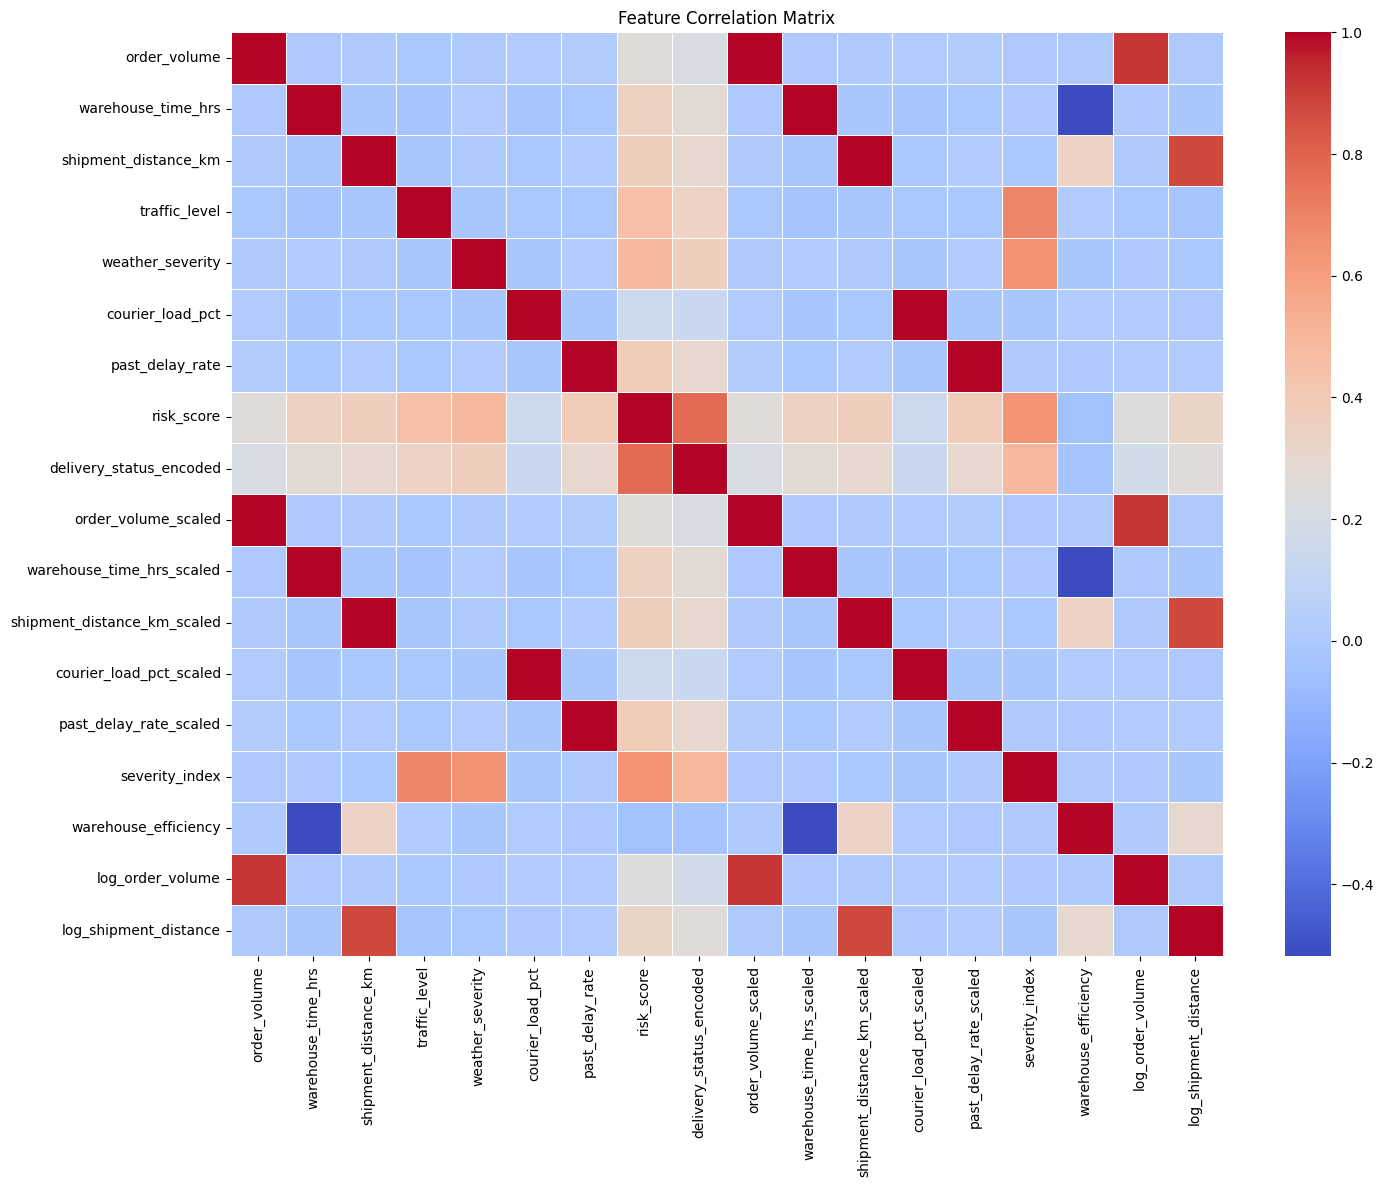

In [32]:
# Correlation Analysis
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [33]:
# Save Processed Data
output_path = '../data/processed/processed_delivery_data.csv'
df.to_csv(output_path, index=False)
print(f"Data saved to {output_path}")

Data saved to ../data/processed/processed_delivery_data.csv
